<a href="https://colab.research.google.com/github/pieupieu16/Analyzing-customer-sentiment-as-a-Data-Analyst-solution/blob/main/Du_doan_khach_hang_roi_di.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DỰ ĐOÁN KHÁCH HÀNG RỜI ĐI

# Kiến thức cần biết

- **CSV File**: Tệp chứa dữ liệu dạng bảng, giống như Excel
- **Pandas**: Thư viện Python để làm việc với dữ liệu
- **Features (Đặc trưng)**: Các cột dữ liệu về khách hàng (tuổi, dịch vụ, ...)
- **X (Input)**: Các thông tin về khách hàng → **ĐẦU VÀO**
- **y (Target/Output)**: Kết quả khách hàng có rời đi hay không → **ĐẦU RA**

In [ ]:
import kagglehub


path = kagglehub.dataset_download("waddahali/e-commerce-customer-churn-audit")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'e-commerce-customer-churn-audit' dataset.
Path to dataset files: /kaggle/input/e-commerce-customer-churn-audit


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,cross_val_score,train_test_split
from sklearn.metrics import accuracy_score,classification_report,f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
warnings.filterwarnings('ignore')
# Cấu hình matplotlib để hiển thị tiếng Việt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
sns.set_style("whitegrid")

In [ ]:
import os

# Đọc file CSV vào Python

df = pd.read_csv(os.path.join(path, 'customer churn.csv'))
print(f"Số dòng (khách hàng): {df.shape[0]:,}")
print(f"Số cột (đặc trưng): {df.shape[1]}")
print(f"\nKích thước: {df.shape}")

Số dòng (khách hàng): 10,300
Số cột (đặc trưng): 10

Kích thước: (10300, 10)


In [ ]:
print(df.head())

   Customer_ID   Gender Region Subscription_Plan Payment_Method   Age  \
0        10001     Male   East             Basic         PayPal  27.0   
1        10002  Unknown   West               Pro         PayPal  55.0   
2        10003   Female   West               Pro       E-Wallet   NaN   
3        10004   Female  south             Basic    Credit Card   NaN   
4        10005     Male  North             Basic         Crypto  30.0   

   Days_Since_Last_Login  Customer_Service_Calls  Monthly_Spend  Churn  
0                     27                       1          61.08      0  
1                    146                       2          73.09      0  
2                    147                       2         116.30      1  
3                     34                       1           0.58      1  
4                    146                       3          46.35      1  


# EDA basic


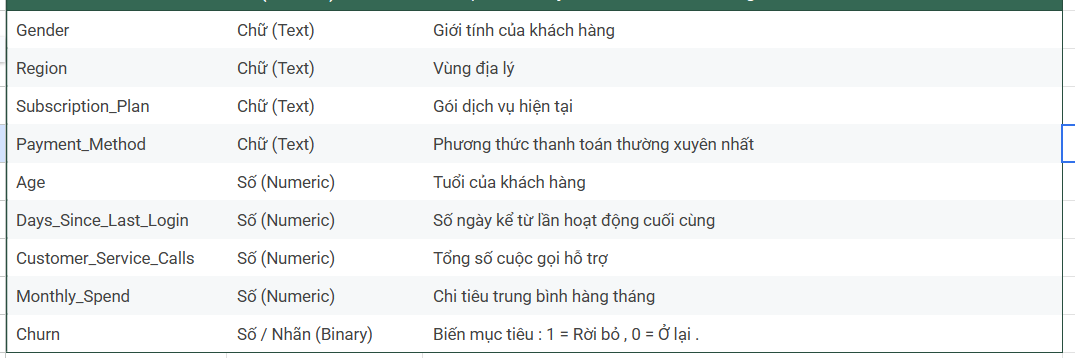
https://www.kaggle.com/datasets/waddahali/e-commerce-customer-churn-audit/data

### Phân bố Churn

Churn
1    7849
0    2451
Name: count, dtype: int64


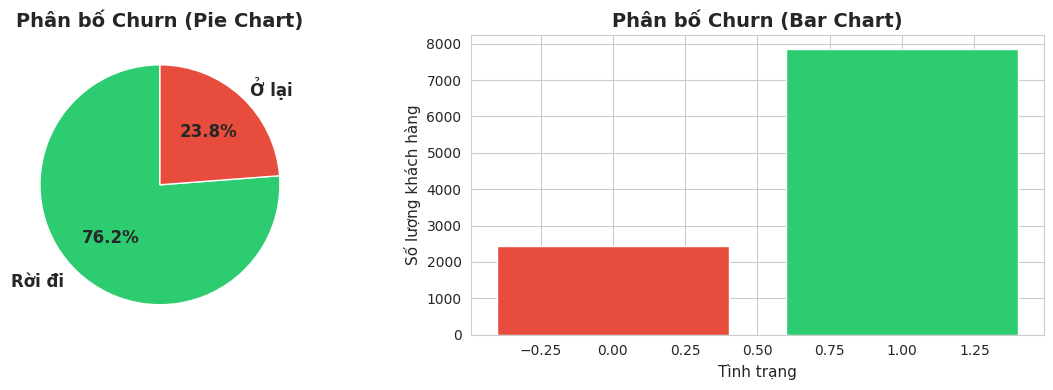

In [ ]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ tròn
axes[0].pie(churn_counts.values,
            labels=['Rời đi ', 'Ở lại'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Phân bố Churn (Pie Chart)', fontsize=14, weight='bold')

# Biểu đồ cột (Bar Chart)
axes[1].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_ylabel('Số lượng khách hàng', fontsize=11)
axes[1].set_xlabel('Tình trạng', fontsize=11)
axes[1].set_title('Phân bố Churn (Bar Chart)', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df.head()

,Customer_ID,Gender,Region,Subscription_Plan,Payment_Method,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn
0,10001,Male,East,Basic,PayPal,27.0,27,1,61.08,0
1,10002,Unknown,West,Pro,PayPal,55.0,146,2,73.09,0
2,10003,Female,West,Pro,E-Wallet,NaN,147,2,116.30,1
3,10004,Female,south,Basic,Credit Card,NaN,34,1,0.58,1
4,10005,Male,North,Basic,Crypto,30.0,146,3,46.35,1


In [ ]:
# Kiểm tra kiểu dữ liệu và thông tin chi tiết
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             10300 non-null  int64  
 1   Gender                  10300 non-null  object 
 2   Region                  10300 non-null  object 
 3   Subscription_Plan       10300 non-null  object 
 4   Payment_Method          9575 non-null   object 
 5   Age                     9267 non-null   float64
 6   Days_Since_Last_Login   10300 non-null  int64  
 7   Customer_Service_Calls  10300 non-null  int64  
 8   Monthly_Spend           9786 non-null   float64
 9   Churn                   10300 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 804.8+ KB
None


In [ ]:
def check(df):
    total_rows = len(df)
    duplicates = df.duplicated().sum()

    dtypes = df.dtypes
    instances = df.count()
    unique = df.nunique()
    sum_null = df.isnull().sum()

    df_check = pd.DataFrame({
        'column': df.columns,
        'dtype': dtypes,
        'instances': instances,
        'unique': unique,
        'sum_null': sum_null,
        'duplicates': duplicates
    })

    return df_check


In [ ]:
df.columns.tolist()

['Customer_ID',
 'Gender',
 'Region',
 'Subscription_Plan',
 'Payment_Method',
 'Age',
 'Days_Since_Last_Login',
 'Customer_Service_Calls',
 'Monthly_Spend',
 'Churn']

In [ ]:
check(df)

,column,dtype,instances,unique,sum_null,duplicates
Customer_ID,Customer_ID,int64,10300,10000,0,300
Gender,Gender,object,10300,4,0,300
Region,Region,object,10300,8,0,300
Subscription_Plan,Subscription_Plan,object,10300,6,0,300
Payment_Method,Payment_Method,object,9575,4,725,300
Age,Age,float64,9267,73,1033,300
Days_Since_Last_Login,Days_Since_Last_Login,int64,10300,180,0,300
Customer_Service_Calls,Customer_Service_Calls,int64,10300,11,0,300
Monthly_Spend,Monthly_Spend,float64,9786,6768,514,300
Churn,Churn,int64,10300,2,0,300


In [ ]:
print(df['Age'].unique())

[ 27.  55.  nan  30.  46.  22.  44.  43.  32.  -5. 150.  35.  19.  38.
  34.  47.  37.  26.  29.  14.  17.  24.  49.  23.  39.  41.  42.  21.
  28.  25.  33.  36.  31.  16.  18.  11.  20.  50.  45.  52.  48.  51.
  40.  53.  15.  12.  59.  58.   9.  62.  57.   8.  13.  54.   0.   4.
  10.   5.  56.   3.  60.  66.  63.   7.  65.  61.   6.  64.  70.  67.
   2.  -1.   1. -10.]


In [ ]:
print(df['Payment_Method'].unique())

['PayPal' 'E-Wallet' 'Credit Card' 'Crypto' nan]


In [ ]:
print(df.columns)

Index(['Customer_ID', 'Gender', 'Region', 'Subscription_Plan',
       'Payment_Method', 'Age', 'Days_Since_Last_Login',
       'Customer_Service_Calls', 'Monthly_Spend', 'Churn'],
      dtype='object')


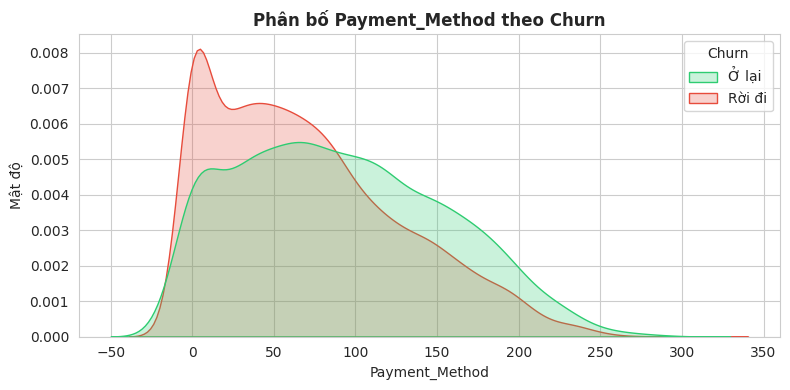

In [ ]:
plt.figure(figsize=(8, 4))
df_filtered = df[df['Monthly_Spend'] < 500]
# Vẽ biểu đồ và lưu lại đối tượng Axes để có thể truy cập vào các thành phần của nó
ax = sns.kdeplot(data=df_filtered, x='Monthly_Spend', hue='Churn', fill=True, common_norm=False, palette=['#2ecc71', '#e74c3c'])
plt.title(f'Phân bố {col} theo Churn', fontsize=12, weight='bold')
plt.xlabel(col)
plt.ylabel('Mật độ')
legend = ax.get_legend()
for t, l in zip(legend.get_texts(), ['Ở lại', 'Rời đi']):
    t.set_text(l)
plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,Customer_ID,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn
count,10300.000000,9267.000000,10300.000000,10300.000000,9786.000000,10300.000000
mean,14859.237864,33.521852,89.449903,1.787379,300.093737,0.762039
std,2959.197492,11.514686,52.088510,1.363470,4733.134612,0.425856
min,10001.000000,-10.000000,0.000000,-1.000000,-10.000000,0.000000
25%,12275.750000,26.000000,44.000000,1.000000,26.275000,1.000000
50%,14850.500000,33.000000,90.000000,2.000000,66.355000,1.000000
75%,17425.250000,40.000000,135.000000,3.000000,115.915000,1.000000
max,20000.000000,150.000000,179.000000,9.000000,99999.990000,1.000000


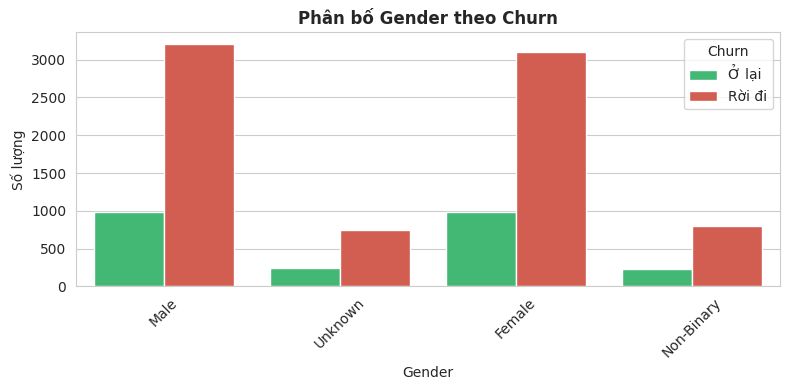

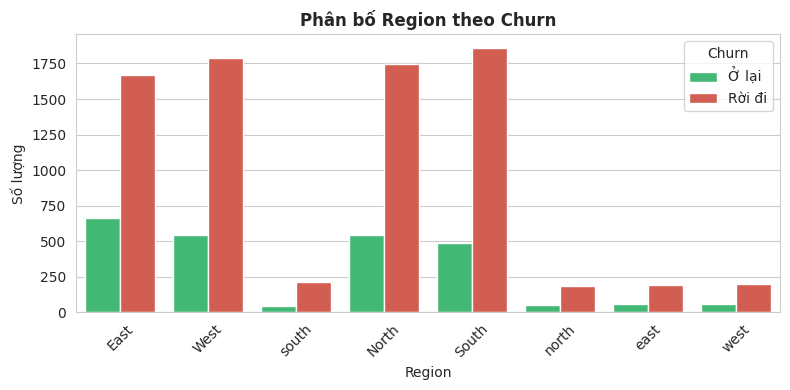

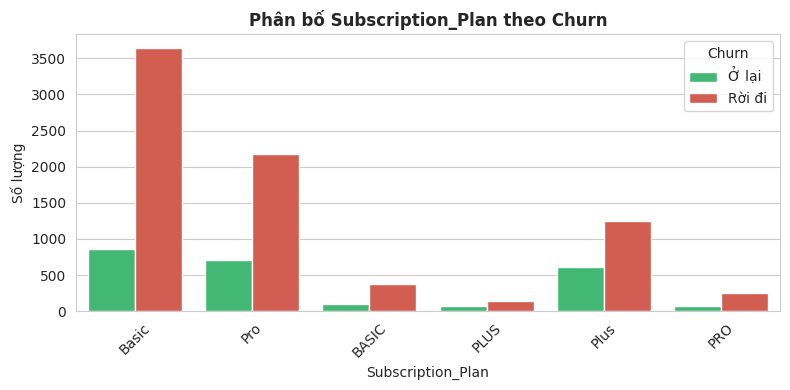

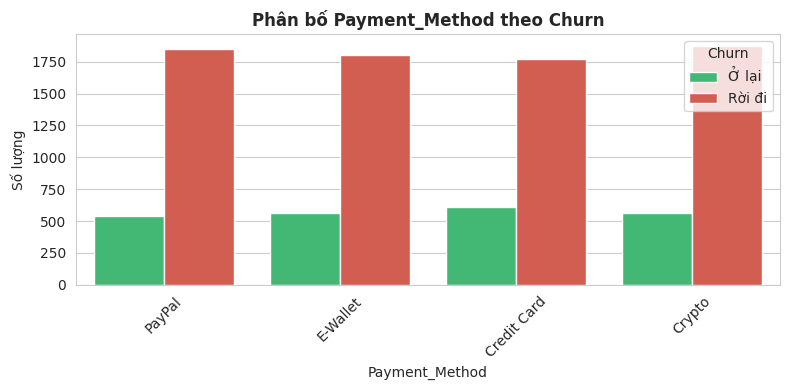

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='Churn', palette=['#2ecc71', '#e74c3c'])
    plt.title(f'Phân bố {col} theo Churn', fontsize=12, weight='bold')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.legend(title='Churn', labels=['Ở lại', 'Rời đi'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
df.describe()

,Customer_ID,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn
count,10300.000000,9267.000000,10300.000000,10300.000000,9786.000000,10300.000000
mean,14859.237864,33.521852,89.449903,1.787379,300.093737,0.762039
std,2959.197492,11.514686,52.088510,1.363470,4733.134612,0.425856
min,10001.000000,-10.000000,0.000000,-1.000000,-10.000000,0.000000
25%,12275.750000,26.000000,44.000000,1.000000,26.275000,1.000000
50%,14850.500000,33.000000,90.000000,2.000000,66.355000,1.000000
75%,17425.250000,40.000000,135.000000,3.000000,115.915000,1.000000
max,20000.000000,150.000000,179.000000,9.000000,99999.990000,1.000000


# TIỀN XỬ LÝ DỮ LIỆU

In [ ]:
if 'Customer_ID' in df.columns:
    df = df.drop('Customer_ID', axis=1)

In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df.loc[df['Age'] < 0, 'Age'] = np.nan # tuổi không thể âm

df.loc[df['Monthly_Spend'] < 0, 'Monthly_Spend'] = np.nan # số tiền không thể âm
df.loc[df['Monthly_Spend'] > 122, 'Monthly_Spend'] = np.nan # tuổi lớn nhất được biết đến hiện tại là 122 tuổi

df.loc[df['Customer_Service_Calls'] < 0, 'Customer_Service_Calls'] = np.nan # số dịch vụ không thể âm



In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop('Churn',axis=1).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

Nếu xử lí thông thường (Không chia train/test trước) sẽ data leakage -> dùng Pipeline để đảm bảo đúng thứ tự

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


In [ ]:
print(df.shape)
df=df.drop_duplicates()
print(df.shape)

(10300, 9)
(9998, 9)


In [ ]:
check(df)

,column,dtype,instances,unique,sum_null,duplicates
Gender,Gender,object,9998,4,0,0
Region,Region,object,9998,8,0,0
Subscription_Plan,Subscription_Plan,object,9998,6,0,0
Payment_Method,Payment_Method,object,9298,4,700,0
Age,Age,float64,8991,70,1007,0
Days_Since_Last_Login,Days_Since_Last_Login,int64,9998,180,0,0
Customer_Service_Calls,Customer_Service_Calls,float64,9948,10,50,0
Monthly_Spend,Monthly_Spend,float64,7290,4823,2708,0
Churn,Churn,int64,9998,2,0,0


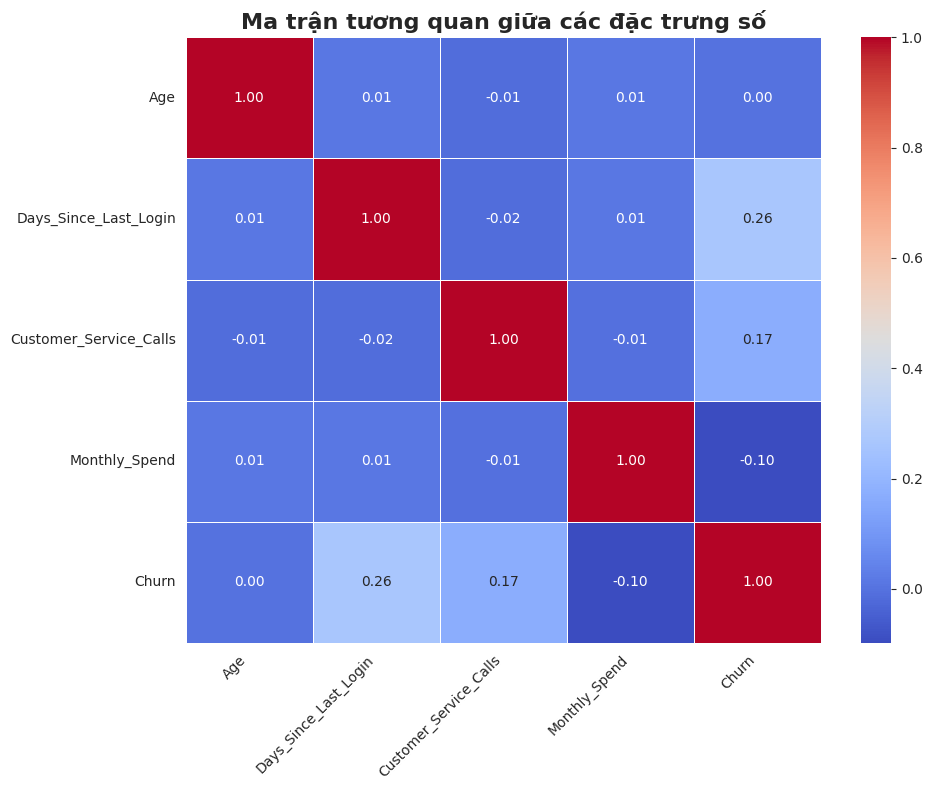

In [ ]:
df_matrix= df.select_dtypes(include=['int64', 'float64']).corr().columns.to_list()
plt.figure(figsize=(10, 8))
sns.heatmap(df[df_matrix].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Ma trận tương quan giữa các đặc trưng số', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Chia tập Train/Test

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Xây dựng mô hình


## Logistic Regression
Thử phương pháp phân loại tuyến tính


#  XÂY DỰNG MÔ HÌNH - LOGISTIC REGRESSION
![image.png](attachment:image.png)


In [ ]:
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
lr_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), #
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
])
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Days_Since_Last_Login',
                                                   'Customer_Service_Calls',
                                                   'Monthly_Spend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Region',
                                                   'Subscription_Plan',
                                                   'Payment_Method'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [ ]:

y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]


threshold = 0.3
y_pred_lr = (y_pred_proba >= threshold).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Tính toán metric
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.1f}%)")
print(f"   F1-Score:  {f1:.4f}")

   Accuracy:  0.7535 (75.3%)
   Precision: 0.8077 (80.8%)
   Recall:    0.8887 (88.9%)
   F1-Score:  0.8463


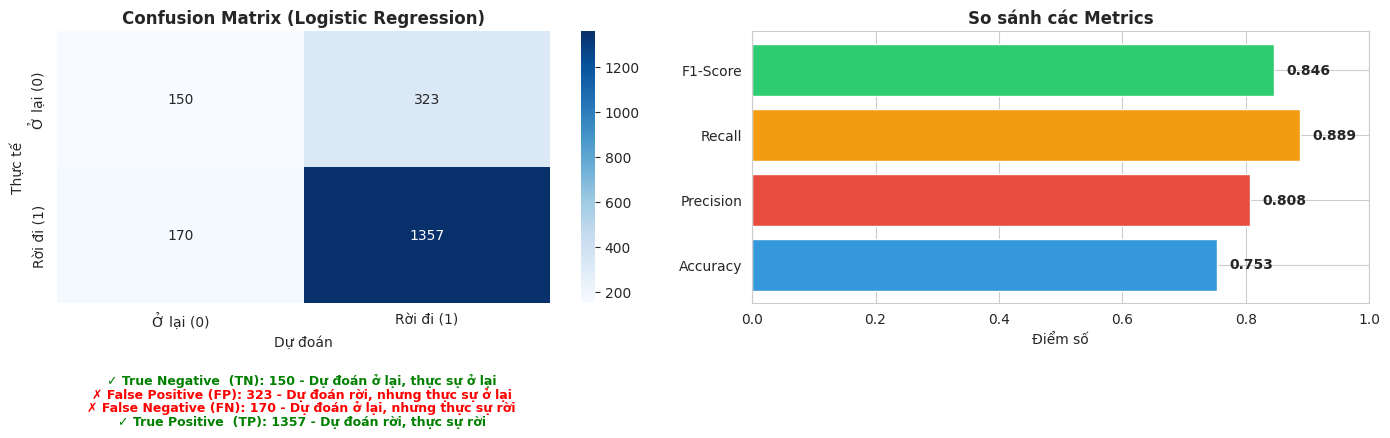

In [ ]:


cm = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ở lại (0)', 'Rời đi (1)'],
            yticklabels=['Ở lại (0)', 'Rời đi (1)'])
axes[0].set_title('Confusion Matrix (Logistic Regression)', fontsize=12, weight='bold')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# Giải thích
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.3, f'✓ True Negative  (TN): {tn} - Dự đoán ở lại, thực sự ở lại ',
            ha='center', transform=axes[0].transAxes, fontsize=9, color='green', weight='bold')
axes[0].text(0.5, -0.35, f'✗ False Positive (FP): {fp} - Dự đoán rời, nhưng thực sự ở lại ',
            ha='center', transform=axes[0].transAxes, fontsize=9, color='red', weight='bold')
axes[0].text(0.5, -0.40, f'✗ False Negative (FN): {fn} - Dự đoán ở lại, nhưng thực sự rời ',
            ha='center', transform=axes[0].transAxes, fontsize=9, color='red', weight='bold')
axes[0].text(0.5, -0.45, f'✓ True Positive  (TP): {tp} - Dự đoán rời, thực sự rời ',
            ha='center', transform=axes[0].transAxes, fontsize=9, color='green', weight='bold')

# Biểu đồ các metric
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

axes[1].barh(metrics_names, metrics_values, color=colors)
axes[1].set_xlabel('Điểm số')
axes[1].set_title('So sánh các Metrics', fontsize=12, weight='bold')
axes[1].set_xlim(0, 1)

for i, v in enumerate(metrics_values):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center', weight='bold')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test,y_pred_lr)
print(f"\nROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_lr)
plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Lí do thuật toán Logisstic Regression tệ:
- Dữ liệu có quá nhiều outlier
- Dữ liệu có mối qua hệ phi tuyến tính
- dữ liệu mất cân bằng

## Random Forest


In [ ]:
model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
model.fit(X_train, y_train)
y_pred_rf = model.predict(X_test)

In [ ]:
## Đánh giá mô hình Random Forest

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Tính toán metric
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.1f}%)")
print(f"   F1-Score:  {f1:.4f}")

   Accuracy:  0.7415 (74.2%)
   Precision: 0.8079 (80.8%)
   Recall:    0.8677 (86.8%)
   F1-Score:  0.8368



## Tuning Random Forest với k=10

In [ ]:
!pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import StratifiedKFold

param_space_rf = {
    'classifier__n_estimators': Integer(50, 200),
    'classifier__max_depth': Integer(3, 15),
    'classifier__min_samples_split': Integer(2, 20),
    'classifier__min_samples_leaf': Integer(1, 10),
    'classifier__max_features': Real(0.1, 1.0, prior='uniform') # or 'sqrt', 'log2'
}


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Kiểm định chéo đặt bằng 5 tối ưu thời gian (có để đặt bàng 10)

bayes_search_rf = BayesSearchCV(
    estimator=model,
    search_spaces=param_space_rf,
    n_iter=50, # Sô lần lặp
    cv=kf,
    scoring='roc_auc', # Tối ưu hóa biểu đồ ROC_ AUC
    n_jobs=-1,
    verbose=2, # độ chi tiết thông tin hiển thị
    random_state=42
)

print("Starting Bayesian Optimization for Random Forest...")
bayes_search_rf.fit(X_train, y_train)

print("Bayesian Optimization complete.")
print(f"Best parameters found: {bayes_search_rf.best_params_}")
print(f"Best ROC AUC score: {bayes_search_rf.best_score_:.4f}")


best_rf_model = bayes_search_rf.best_estimator_


y_pred_tuned_rf = best_rf_model.predict(X_test)
y_pred_proba_tuned_rf = best_rf_model.predict_proba(X_test)[:, 1] # xem thử độ tin cậy với mỗi lần dự đoán

print("\n--- Performance of Best Tuned Random Forest Model at various thresholds ---")
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:

  y_pred_tuned_rf_thresh = (y_pred_proba_tuned_rf >= threshold).astype(int)


  accuracy_tuned = accuracy_score(y_test, y_pred_tuned_rf_thresh)
  precision_tuned = precision_score(y_test, y_pred_tuned_rf_thresh)
  recall_tuned = recall_score(y_test, y_pred_tuned_rf_thresh)
  f1_tuned = f1_score(y_test, y_pred_tuned_rf_thresh)

  print(f"\n--- Threshold: {threshold:.2f} ---")
  print(f"   Accuracy:  {accuracy_tuned:.4f} ({accuracy_tuned*100:.1f}%)")
  print(f"   Precision: {precision_tuned:.4f} ({precision_tuned*100:.1f}%)")
  print(f"   Recall:    {recall_tuned:.4f} ({recall_tuned*100:.1f}%)")
  print(f"   F1-Score:  {f1_tuned:.4f}")

Starting Bayesian Optimization for Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitt

In [ ]:
print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred_tuned_rf))


===== Classification Report =====
              precision    recall  f1-score   support

           0       0.38      0.62      0.47       473
           1       0.85      0.69      0.76      1527

    accuracy                           0.67      2000
   macro avg       0.62      0.65      0.62      2000
weighted avg       0.74      0.67      0.69      2000




ROC AUC Score: 0.7052


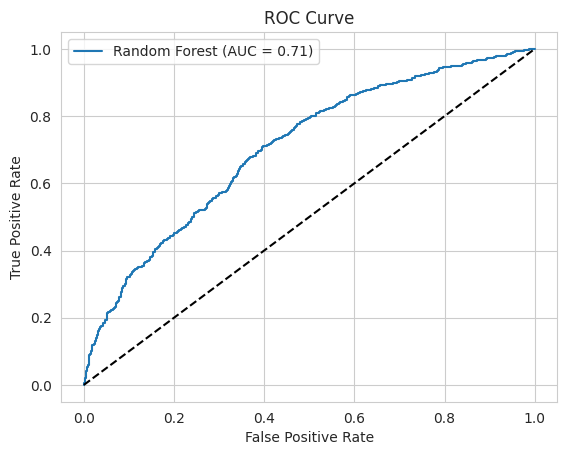

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test,y_pred_proba_tuned_rf)
print(f"\nROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_tuned_rf)
plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

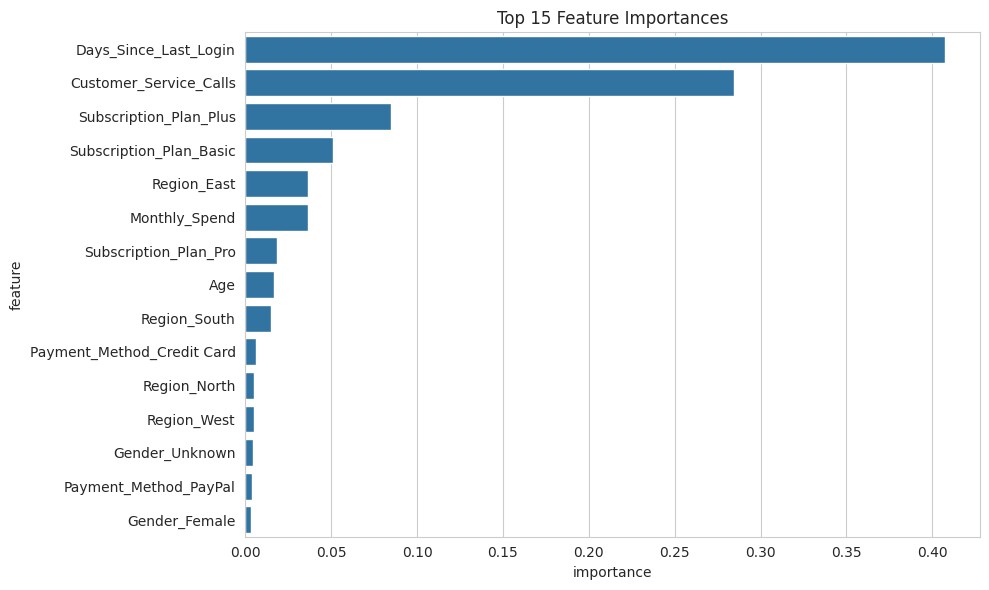

In [ ]:
preprocessor_fitted = best_rf_model.named_steps['preprocessor']
cat_feature_names = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(cat_feature_names)

importances = best_rf_model.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()


--- SHAP Summary Plot ---


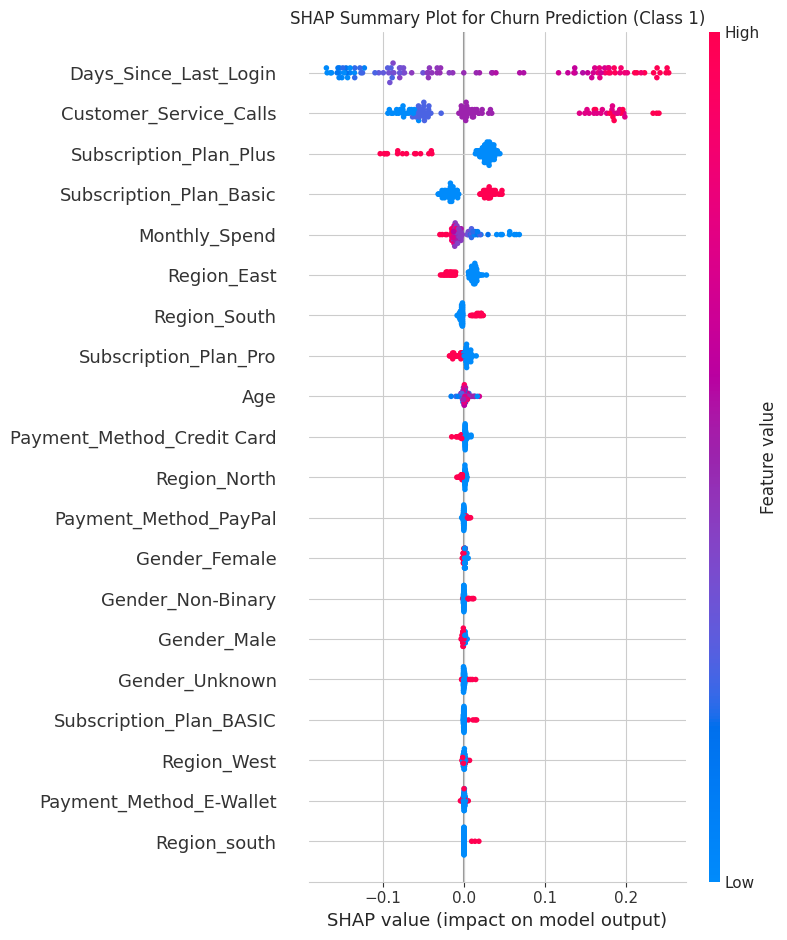


--- SHAP Dependence Plot for Days_Since_Last_Login ---


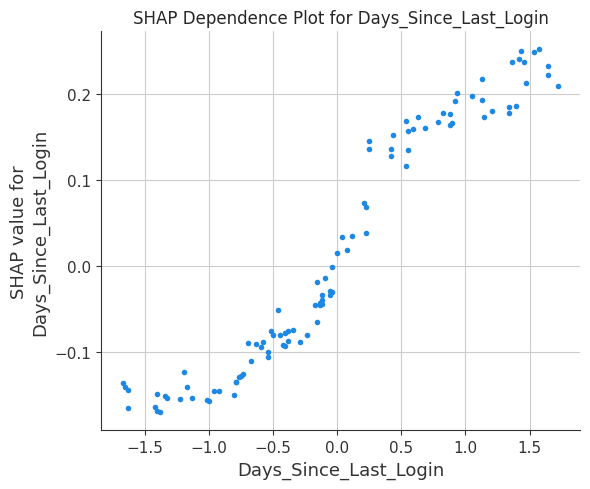

In [ ]:

!pip install shap

import shap
import matplotlib.pyplot as plt

preprocessor_pipeline = best_rf_model.named_steps['preprocessor']
rf_classifier = best_rf_model.named_steps['classifier']


X_test_processed = preprocessor_pipeline.transform(X_test)



X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names)

explainer = shap.TreeExplainer(rf_classifier)

sampled_X_test_processed_df = X_test_processed_df.sample(100, random_state=42)
shap_values = explainer.shap_values(sampled_X_test_processed_df)

print("\n--- SHAP Summary Plot ---")
# Visualize the SHAP values for class 1
shap.summary_plot(shap_values[:, :, 1], sampled_X_test_processed_df, show=False)
plt.title('SHAP Summary Plot for Churn Prediction (Class 1)')
plt.tight_layout()
plt.show()


Thuật toán đã học được mối quan hệ phi tuyến

###  BẢNG SO SÁNH HIỆU NĂNG Ở CÙNG NGƯỠNG DỰ ĐOÁN (THRESHOLD = 0.3)



| Chỉ số (Metric) | Logistic Regression <br>*(Threshold = 0.3)* | Random Forest (Tuned) <br>*(Threshold = 0.3)* | Nhận xét xu hướng |
| :--- | :---: | :---: | :--- |
| **Accuracy** *(Độ chính xác tổng thể)* | 75.3% | **76.5%** | **Random Forest** phân loại chính xác toàn cục tốt hơn một chút (~1.2%). |
| **Precision** *(Độ tin cậy nhãn Churn)* | 80.8% | **78.3%** | **Logistic** nhỉnh hơn 2.5%, nghĩa là tỷ lệ báo động nhầm của Logistic thấp hơn một chút ở ngưỡng này. |
| **Recall** *(Tỷ lệ bắt trúng Churn)* | 88.9% | **95.9%** | **Random Forest thắng áp đảo (~7%)**. Mô hình cây đã tóm gọn được tới 95.9% tổng số khách hàng thực tế sắp rời đi, hạn chế tối đa việc lọt lưới. |
| **F1-Score** *(Điểm trung bình điều hòa)* | 0.8463 | **0.8620** | **Random Forest** đạt điểm cân bằng F1 cao hơn hẳn nhờ chỉ số Recall vượt trội. |

>  **KẾT LUẬN:**
> Khi đặt ở cùng một vạch xuất phát là `Threshold = 0.3`, mô hình **Random Forest (Tuned)** thể hiện sự vượt trội rõ rệt . Với điểm **Recall lên tới 95.9%** và **F1-Score đạt 0.8620**.